# Creating Custom Scatterers (including Biological Scatterers)

TODO: add link to Colab

In [ ]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

DeepTrack2 allows you to simulate microscopy images be generating scatterers, which are abstract representations of objects that scatter light. These scatterers can then be passed through an optical model to produce images.

In this tutorial, you will learn how scatterers are defined in DeepTrack, how to create a custom scatterer of a specific shape, and how to defince scatterers inspired by biological structures.

In [2]:
import deeptrack as dt
import matplotlib.pyplot as plt
import numpy as np

## 1. Understanding Scatterers in DeepTrack
Scatterers are defined in three-dimensional voxel space. A voxel is a small cube in 3D space, analogous to a pixel in a 2D image. Each voxel has a value representing whether the scatterer occupies it, either being `True` or `False`.

### 1.1 Creating a 3D Scatterer

To create a scatterer, you first generate a three-dimensional grid of voxel coordinates. Then you evaluate a function at each voxel to determine whether it belongs to the scatterer, producing a boolean mask.

For example, a spherical scatterer can be defined by the function $(X^2 + Y^2 + Z^2) < R^2$. Here, $X$, $Y$, and $Z$ are the voxel coordinates, and $R$ is the sphere radius. Using this function as a mask will assign `True` to the voxels inside the sphere and `False` to voxels outside.

In [3]:
# Set up the grid
x = np.arange(-12, 12)
y = np.arange(-12, 12)
z = np.arange(-12, 12)
Y, X, Z = np.meshgrid(y, x, z)

# Set the radius of the sphere
radius = 11

# Create the mask for the sphere
mask = (X**2 + Y**2 + Z**2) < radius**2

Here, `mask` is a 3D boolean array representing the scatterer. You can visualize it using `ax.voxels`:

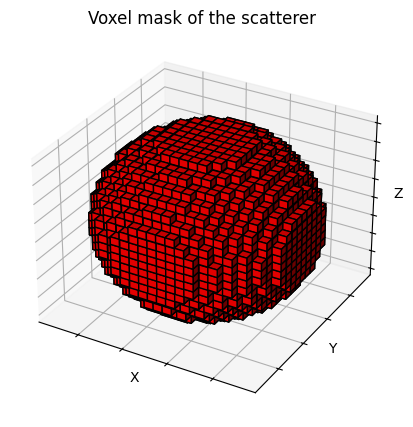

In [4]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')

ax.voxels(mask, facecolors='red', edgecolor='k')

ax.set(title='Voxel mask of the scatterer', xlabel='X', ylabel='Y', zlabel='Z')
ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
ax.xaxis.labelpad = ax.yaxis.labelpad = ax.zaxis.labelpad=-10

plt.show()

### 1.2 Creating a 2D Scatterer

For a **2D scatterer**, you only need to define the grid and specify your mask in the $X$ and $Y$ dimensions. To create a circle analogous to the sphere above, you can define the grid and mask as follows:

In [5]:
x = np.arange(-12, 12)
y = np.arange(-12, 12)
Y, X = np.meshgrid(y, x)

radius = 11
mask_2d = (X**2 + Y**2) < radius**2

## 2. Creating a Custom Scatterer Class

To create a reusable scatterer, you can subclass `dt.Scatterer`. This ensures that your scatterer integrates seamlessly with DeepTrack's pipeline and can be used directly with DeepTrack's optical models.

When subclassing `dt.Scatterer`, the main task is to define the shape of your scatterer by implementing the `get()` method. This method should return a 3D array representing voxel occupancy. Optionally, you can override _process_properties to validate or reshape user-provided parameters, such as radius, length, or rotation.

### 2.1 Create a Cylinder Scatterer

As a concrete example, you can create a cylinder scatterer. This cylinder is defined by its radii along the X and Z axes, its length along the Y axis, and a rotation vector specifying rotations around the X, Y, and Z axes. The class definition begins by specifying a conversion table for the parameters that you are going to use, and by initializing the scatterer with the desired parameters.

In [ ]:
# Depending on your installed version of Deeptrack, you might have to exchange
# the next line for "from deeptrack import units_registry as u"
from deeptrack import units as u
from deeptrack.backend.units import ConversionTable

class CustomCylinder(dt.Scatterer):
    __conversion_table__ = ConversionTable(
        radius=(u.meter, u.meter),
        length=(u.meter, u.meter),
        rotation=(u.radian, u.radian),
    )

    def __init__(
            self,
            radius=1e-6,
            length=2e-6,
            rotation=(0, 0, 0),
            **kwargs
        ):
        super().__init__(
            radius=radius,
            length=length,
            rotation=rotation,
            **kwargs
        )

The `get()` method is where the scatterer’s voxel representation is generated. First, a 3D meshgrid is created to cover the space where the scatterer will exist. The size of the meshgrid should be chosen to fully contain the scatterer. In practice, we take the maximum of the radius (or radii, if anisotropic) and the half-length of the cylinder, divide them by the voxel size, and round up to ensure the grid extends far enough in each direction. This ensures that no part of the scatterer is cut off.

Next, the grid coordinates are rotated according to the user-provided rotation angles. Here, the rotation angles are set as three angles in radians corresponding to rotations around the X, Y, and Z axes. These rotations are applied using a standard rotation matrix.

Finally, the mask is defined. For a cylinder oriented along the Y axis, we select all voxels that satisfy two conditions: they lie within the cylinder radius in the X–Z plane, and they lie within the cylinder length along the Y axis. This boolean mask is returned as the voxel representation of the scatterer.

In [7]:
def get(
    self,
    *ignore, # catches unused positional arguments
    radius,
    length,
    rotation,
    voxel_size,
    **kwargs
):

    # Determine grid size
    rad_ceil = np.ceil(np.max(radius) / np.min(voxel_size[:2]))
    len_ceil = np.ceil(length * 0.5 / voxel_size[2])
    ceil = int(max(rad_ceil, len_ceil))

    # Create grid
    x = np.arange(-ceil, ceil) * voxel_size[0]
    y = np.arange(-ceil, ceil) * voxel_size[1]
    z = np.arange(-ceil, ceil) * voxel_size[2]
    Y, X, Z = np.meshgrid(y, x, z)

    # Rotate the grid
    cos = np.cos(rotation)
    sin = np.sin(rotation)
    XR = (
        cos[0] * cos[1] * X
        + (cos[0] * sin[1] * sin[2] - sin[0] * cos[2]) * Y
        + (cos[0] * sin[1] * cos[2] + sin[0] * sin[2]) * Z
    )
    YR = (
        sin[0] * cos[1] * X
        + (sin[0] * sin[1] * sin[2] + cos[0] * cos[2]) * Y
        + (sin[0] * sin[1] * cos[2] - cos[0] * sin[2]) * Z
    )
    ZR = (-sin[1] * X) + cos[1] * sin[2] * Y + cos[1] * cos[2] * Z

    # Cylinder mask
    mask = ((XR**2 / radius[0] ** 2 + ZR**2 / radius[1] ** 2) < 1) & (
        np.abs(YR) < length / 2
    )

    return mask.astype(float)

To ensure that the input parameters have the correct shape, you can add the `_process_properties` method. For the cylinder, the radius will be converted into a length-two array, the length is converted to a scalar and the rotation is padded or truncated to a length-three tuple:

In [8]:
def _process_properties(self, properties):
    properties = super()._process_properties(properties)

    # Ensure radius is of length 2
    radius = np.array(properties["radius"])
    if radius.ndim == 0:
        radius = np.array((properties["radius"], properties["radius"]))
    elif radius.size == 1:
        radius = np.array((*radius,) * 2)
    else:
        radius = radius[:2]
    properties["radius"] = radius

    # Ensure length is scalar
    properties["length"] = float(properties["length"])

    # Ensure rotation is 3 values
    rotation = np.array(properties["rotation"])
    if rotation.ndim == 0:
        rotation = [rotation, 0, 0]
    elif rotation.size == 1:
        rotation = [rotation[0], 0, 0]
    elif rotation.size == 2:
        rotation = [rotation[0], rotation[1], 0]
    properties["rotation"] = tuple(rotation)

    return properties

Putting all of these parts together you get the class for the cylinder scatterer:

In [9]:
class Cylinder(dt.Scatterer):
    __conversion_table__ = ConversionTable(
        radius=(u.meter, u.meter),
        length=(u.meter, u.meter),
        rotation=(u.radian, u.radian),
    )

    def __init__(
            self,
            radius=1e-6,
            length=2e-6,
            rotation=(0, 0, 0),
            **kwargs
        ):
        super().__init__(
            radius=radius,
            length=length,
            rotation=rotation,
            **kwargs
        )

    def _process_properties(self, properties):
        properties = super()._process_properties(properties)

        # Ensure radius is of length 2
        radius = np.array(properties["radius"])
        if radius.ndim == 0:
            radius = np.array((properties["radius"], properties["radius"]))
        elif radius.size == 1:
            radius = np.array((*radius,) * 2)
        else:
            radius = radius[:2]
        properties["radius"] = radius

        # Ensure length is scalar
        properties["length"] = float(properties["length"])

        # Ensure rotation is 3 values
        rotation = np.array(properties["rotation"])
        if rotation.ndim == 0:
            rotation = [rotation, 0, 0]
        elif rotation.size == 1:
            rotation = [rotation[0], 0, 0]
        elif rotation.size == 2:
            rotation = [rotation[0], rotation[1], 0]
        properties["rotation"] = tuple(rotation)

        return properties

    def get(
        self,
        *ignore,
        radius,
        length,
        rotation,
        voxel_size,
        **kwargs
    ):

        # Determine grid size
        rad_ceil = np.ceil(np.max(radius) / np.min(voxel_size[:2]))
        len_ceil = np.ceil(length * 0.5 / voxel_size[2])
        ceil = int(max(rad_ceil, len_ceil))

        # Create grid
        x = np.arange(-ceil, ceil) * voxel_size[0]
        y = np.arange(-ceil, ceil) * voxel_size[1]
        z = np.arange(-ceil, ceil) * voxel_size[2]
        Y, X, Z = np.meshgrid(y, x, z)

        # Rotate the grid
        cos = np.cos(rotation)
        sin = np.sin(rotation)
        XR = (
            cos[0] * cos[1] * X
            + (cos[0] * sin[1] * sin[2] - sin[0] * cos[2]) * Y
            + (cos[0] * sin[1] * cos[2] + sin[0] * sin[2]) * Z
        )
        YR = (
            sin[0] * cos[1] * X
            + (sin[0] * sin[1] * sin[2] + cos[0] * cos[2]) * Y
            + (sin[0] * sin[1] * cos[2] - cos[0] * sin[2]) * Z
        )
        ZR = (-sin[1] * X) + cos[1] * sin[2] * Y + cos[1] * cos[2] * Z

        # Cylinder mask
        mask = ((XR**2 / radius[0] ** 2 + ZR**2 / radius[1] ** 2) < 1) & (
            np.abs(YR) < length / 2
        )

        return mask.astype(float)

### 2.2 Using the Custom Cylinder Scatterer in a Pipeline

You can now use your cylinder like any built-in DeepTrack scatterer. To create a simple pipeline, you can first define the cylinder with a chosen radius, length and position.

In [10]:
radius = (7e-7, 3e-7)
length = 4e-6
position = (64, 64)

cylinder = Cylinder(
    radius=radius,
    length=length,
    position=position,
)

Next, define the optical setup, for example a fluorescence microscope, and apply it to your scatterer to create a pipeline.

In [11]:
optics = dt.Fluorescence()

pip = optics(cylinder)

Resolving the pipeline produces an image of the scatterer.

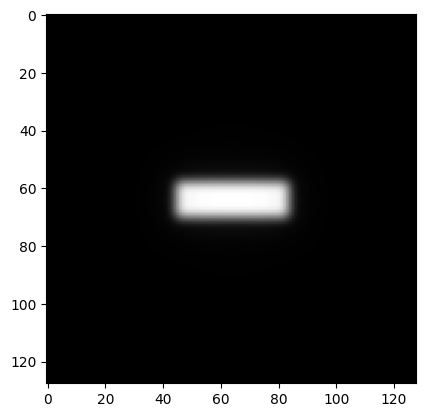

In [12]:
pip.update()
image1 = pip.resolve()

plt.imshow(image1, cmap='gray');

The orientation of the scatterer can also be varied through the `rotation` parameter. By changing the angles, you can explore how the same object appears when viewed at different orientations:

Rotate around z-axis:

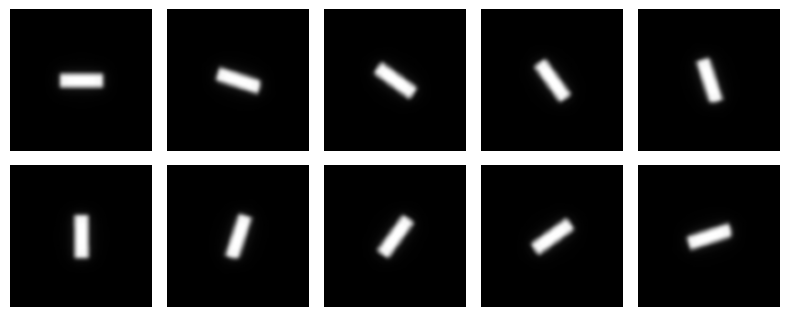

In [13]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3.3))

for i in range(10):

    cylinder = Cylinder(
        radius=radius,
        length=length,
        rotation=(i * np.pi / 10, 0, 0),  # rotation around Z-axis
        position=position
    )

    pip = optics(cylinder)

    pip.update()
    image = pip.resolve()

    ax[int(i*0.4 // 2), i%5].imshow(image, cmap='gray')
    ax[int(i*0.4 // 2), i%5].axis('off')   # remove axes for a cleaner look

plt.subplots_adjust(wspace=0, hspace=0) 
plt.tight_layout()
plt.show()

Rotate around x-axis:

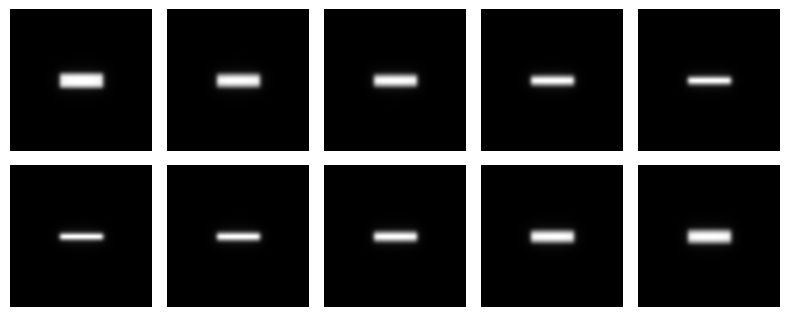

In [14]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3.3))

for i in range(10):

    cylinder = Cylinder(
        radius=radius,
        length=length,
        rotation=(0, i * np.pi / 10, 0), # rotation around X-axis
        position=position,
    )

    pip = optics(cylinder)

    pip.update()
    image = pip.resolve()

    ax[int(i*0.4 // 2), i%5].imshow(image, cmap='gray')
    ax[int(i*0.4 // 2), i%5].axis('off')

plt.subplots_adjust(wspace=0, hspace=0) 
plt.tight_layout()
plt.show()

Rotate around y-axis:

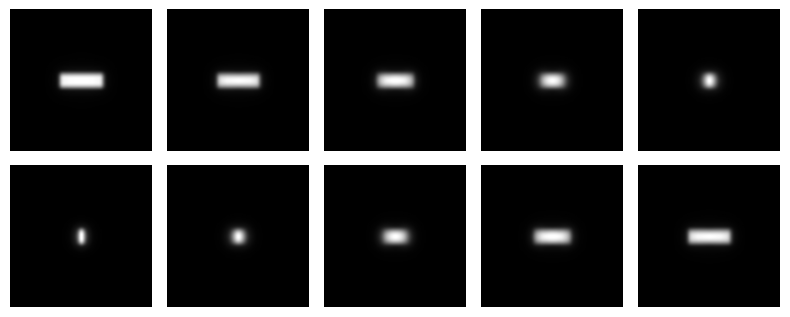

In [15]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3.3))

for i in range(10):

    cylinder = Cylinder(
        radius=radius,
        length=length,
        rotation=(0, 0, i * np.pi / 10),  # rotation around Y-axis
        position=position
    )

    pip = optics(cylinder)

    pip.update()
    image = pip.resolve()

    ax[int(i*0.4 // 2), i%5].imshow(image, cmap='gray')
    ax[int(i*0.4 // 2), i%5].axis('off')

plt.subplots_adjust(wspace=0, hspace=0) 
plt.tight_layout()
plt.show()

### 2.3 Adapting the Scatterer

You can also create other shapes for your scatterer by modifying the mask function. For example, a wavy cylinder can be generated by adding a sinusoidal modulation to the radius along the cylinder’s axis. When doing this, make sure to slightly increase the maximum size of the meshgrid so that the entire scatterer, including the waves, is fully contained.

In [16]:
class WavyCylinder(dt.Scatterer):
    __conversion_table__ = ConversionTable(
        radius=(u.meter, u.meter),
        length=(u.meter, u.meter),
        rotation=(u.radian, u.radian),
    )

    def __init__(
        self,
        radius=1e-6,
        length=2e-6,
        rotation=(0, 0, 0),
        amplitude=0.5,
        frequency=3,
        **kwargs
    ):
        super().__init__(
            radius=radius,
            length=length,
            rotation=rotation,
            amplitude=amplitude,
            frequency=frequency,
            **kwargs
        )

    def _process_properties(self, properties: dict) -> dict:
        properties = super()._process_properties(properties)

        # Ensure radius is of length 2
        radius = np.array(properties["radius"])
        if radius.ndim == 0:
            radius = np.array((properties["radius"], properties["radius"]))
        elif radius.size == 1:
            radius = np.array((*radius,) * 2)
        else:
            radius = radius[:2]
        properties["radius"] = radius

        # Ensure length is scalar
        properties["length"] = float(properties["length"])

        # Ensure rotation is 3 values
        rotation = np.array(properties["rotation"])
        if rotation.ndim == 0:
            rotation = [rotation, 0, 0]
        elif rotation.size == 1:
            rotation = [rotation[0], 0, 0]
        elif rotation.size == 2:
            rotation = [rotation[0], rotation[1], 0]
        properties["rotation"] = tuple(rotation)

        return properties

    def get(
        self,
        *ignore,
        radius,
        length,
        rotation,
        amplitude,
        frequency,
        voxel_size,
        **kwargs
    ):
        # Grid size
        rad_ceil = np.ceil((np.max(radius) ) / np.min(voxel_size[:2])) * (1 + amplitude)
        len_ceil = np.ceil(length * 0.5 / voxel_size[2])
        ceil = int(max(rad_ceil, len_ceil))

        # Grid
        x = np.arange(-ceil, ceil) * voxel_size[0]
        y = np.arange(-ceil, ceil) * voxel_size[1]
        z = np.arange(-ceil, ceil) * voxel_size[2]
        Y, X, Z = np.meshgrid(y, x, z)

        # Rotate grid if needed (same as ellipsoid)
        cos = np.cos(rotation)
        sin = np.sin(rotation)
        XR = (
            cos[0] * cos[1] * X
            + (cos[0] * sin[1] * sin[2] - sin[0] * cos[2]) * Y
            + (cos[0] * sin[1] * cos[2] + sin[0] * sin[2]) * Z
        )
        YR = (
            sin[0] * cos[1] * X
            + (sin[0] * sin[1] * sin[2] + cos[0] * cos[2]) * Y
            + (sin[0] * sin[1] * cos[2] - cos[0] * sin[2]) * Z
        )
        ZR = (-sin[1] * X) + cos[1] * sin[2] * Y + cos[1] * cos[2] * Z

        # Wavy cylinder mask
        radius_wave = radius[0] + amplitude * radius[0] * np.sin(
            frequency * YR * 2 * np.pi / length
        )
        mask = (
            (XR**2 / radius_wave**2 + ZR**2 / radius[1] ** 2) < 1
        ) & (np.abs(YR) < (length / 2))

        return mask.astype(float)

In [17]:
wavy_cylinder = WavyCylinder(
    radius=radius,
    length=5e-6,
    position=position,
)

pip_wavy_cylinder = optics(wavy_cylinder)

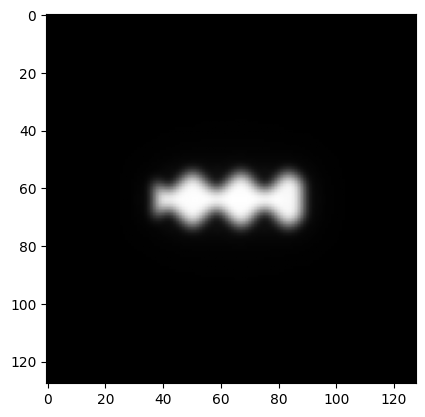

In [18]:
pip_wavy_cylinder.update()

image = pip_wavy_cylinder.resolve()

plt.imshow(image, cmap='gray');

## 3. Biological scatterers: Bacteria

In addition to simple geometric scatterers, DeepTrack also makes it possible to describe biological structures with more complex shapes. The examples below show how common bacterial morphologies can be represented as scatterers. These implementations are not intended as exact models of bacterial structure, but rather as demonstrations of how such scatterers can be created and adapted. You can use them directly, or take them as inspiration to design custom scatterers that fit your own application.

### 3.1 Bacillus

Rod-shaped bacteria (bacilli) can be represented by combining a cylinder with hemispherical caps. The example `Bacillus` class below also includes the option to add bending along the length of the rod, which can make the shape look more natural.

In [19]:
class Bacillus(dt.Scatterer):
    __conversion_table__ = ConversionTable(
        radius=(u.meter, u.meter),
        length=(u.meter, u.meter),
        rotation=(u.radian, u.radian),
    )

    def __init__(
            self,
            radius=0.5e-6,
            length=2e-6,
            rotation=(0, 0, 0),
            max_bacillus_bend=0,
            **kwargs
        ):
        super().__init__(
            radius=radius,
            length=length,
            rotation=rotation,
            max_bacillus_bend=max_bacillus_bend,
            **kwargs
        )

    def _process_properties(self, properties):
        properties = super()._process_properties(properties)

        # Ensure radius iis scalar
        radius = np.array(properties["radius"])
        if radius.size > 1:
            radius = radius[0]
        properties["radius"] = float(radius)

        # Ensure length is scalar
        properties["length"] = float(properties["length"])

        # Ensure rotation is 3 values
        rotation = np.array(properties["rotation"])
        if rotation.ndim == 0:
            rotation = [rotation, 0, 0]
        elif rotation.size == 1:
            rotation = [rotation[0], 0, 0]
        elif rotation.size == 2:
            rotation = [rotation[0], rotation[1], 0]
        properties["rotation"] = tuple(rotation)

        return properties

    def get(
        self,
        *ignore,
        radius,
        length,
        rotation,
        max_bacillus_bend,
        voxel_size,
        **kwargs
    ):

        # Determine grid size
        rad_ceil = np.ceil(radius / np.min(voxel_size[:2]))
        len_ceil = np.ceil(length * 0.5 / voxel_size[2]) + rad_ceil
        ceil = int(max(rad_ceil, len_ceil))

        # Create the grid
        x = np.arange(-ceil, ceil) * voxel_size[0]
        y = np.arange(-ceil, ceil) * voxel_size[1]
        z = np.arange(-ceil, ceil) * voxel_size[2]
        Y, X, Z = np.meshgrid(y, x, z)

        # Rotate the grid
        cos = np.cos(rotation)
        sin = np.sin(rotation)
        XR = (
            cos[0] * cos[1] * X
            + (cos[0] * sin[1] * sin[2] - sin[0] * cos[2]) * Y
            + (cos[0] * sin[1] * cos[2] + sin[0] * sin[2]) * Z
        )
        YR = (
            sin[0] * cos[1] * X
            + (sin[0] * sin[1] * sin[2] + cos[0] * cos[2]) * Y
            + (sin[0] * sin[1] * cos[2] - cos[0] * sin[2]) * Z
        )
        ZR = (-sin[1] * X) + cos[1] * sin[2] * Y + cos[1] * cos[2] * Z

        # Apply wave-like bending along the lenght of the bacillus
        bend_amp_x = (np.random.rand() - 0.5) * 2 * max_bacillus_bend
        bend_amp_z = (np.random.rand() - 0.5) * 2 * max_bacillus_bend
        lateral_offset_x = bend_amp_x * np.cos(np.pi * YR / length)
        lateral_offset_z = bend_amp_z * np.cos(np.pi * YR / length)
        XR -= lateral_offset_x
        ZR -= lateral_offset_z
        
        # Cylinder mask
        cyl_mask = ((XR**2 / radius ** 2 + ZR**2 / radius ** 2) < 1) & (
            np.abs(YR) < (length / 2)
        )
        # Hemispherical caps
        cap_mask = ((XR**2 + ZR**2 + (np.abs(YR) - (length/2))**2) < radius**2)

        # Combine the cylinder with the end-caps to form the full bacillus shape
        mask = cyl_mask | cap_mask

        return mask.astype(float)

In [20]:
bacillus = Bacillus(
    position=(64, 64),
)

optics = dt.Fluorescence()

pip = optics(bacillus)

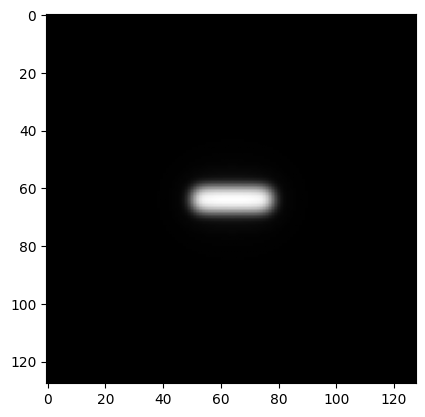

In [21]:
pip.update()
image = pip.resolve()
plt.imshow(image, cmap='gray');

Once defined, bacilli can be placed at specific positions, given random orientations, and varied in size. Several instances can be combined into the same simulation, with tools such as `NonOverlapping` to avoid unrealistic overlaps, or transformations to introduce further variability.

In [22]:
bacillus = Bacillus(
    position=lambda: np.random.uniform(0, 128, 2),
    rotation=lambda: np.random.uniform(0, 2*np.pi),
    length=lambda: np.random.uniform(1.6e-6, 2.6e-6),
    max_bacillus_bend=1e-7,
)

multiple_bacilli = (bacillus ^ (lambda: np.random.randint(5, 10)))

non_overlap_bac = dt.NonOverlapping(multiple_bacilli, min_distance=3)

pip = optics(non_overlap_bac)

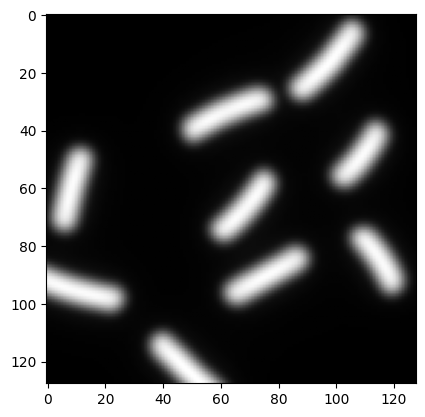

In [24]:
pip.update()
image = pip.resolve()
plt.imshow(image, cmap='gray');

### 3.2 Streptobacillus
Streptobacilli are bacteria that form chains of bacilli. This can be modeled by arranging multiple bacilli end-to-end. The class below allows both the individual rods and the entire chain to bend slightly, which can give rise to realistic chain-like structures.

In [25]:
class Streptobacillus(dt.Scatterer):
    __conversion_table__ = ConversionTable(
        radius=(u.meter, u.meter),
        length=(u.meter, u.meter),
        rotation=(u.radian, u.radian),
    )

    def __init__(
            self,
            radius=0.5e-6,
            length=2e-6,
            n_bacilli=5,
            rotation=(0, 0, 0),
            max_chain_bend=0,
            max_bacillus_bend=0,
            **kwargs
        ):
        super().__init__(
            radius=radius,
            length=length,          # length of each part of the chain
            n_bacilli=n_bacilli,
            rotation=rotation,
            max_chain_bend=max_chain_bend,
            max_bacillus_bend=max_bacillus_bend,
            **kwargs
        )

    def _process_properties(self, properties):
        properties = super()._process_properties(properties)

        # Ensure radius iis scalar
        radius = np.array(properties["radius"])
        if radius.size > 1:
            radius = radius[0]
        properties["radius"] = float(radius)

        # # Ensure length is scalar
        # properties["length"] = float(properties["length"])

        # Ensure length is float or iterable of floats
        length = properties["length"]
        if np.ndim(length) == 0:
            properties["length"] = float(length)
        else:
            properties["length"] = np.array(length, dtype=float)

        # Ensure n_bacilli is int
        properties["n_bacilli"] = int(properties.get("n_bacilli"))

        # Ensure rotation is 3 values
        rotation = np.array(properties["rotation"])
        if rotation.ndim == 0:
            rotation = [rotation, 0, 0]
        elif rotation.size == 1:
            rotation = [rotation[0], 0, 0]
        elif rotation.size == 2:
            rotation = [rotation[0], rotation[1], 0]
        properties["rotation"] = tuple(rotation)

        return properties

    def get(
        self,
        *ignore,
        radius,
        length,
        n_bacilli,
        rotation,
        max_chain_bend,
        max_bacillus_bend,
        voxel_size,
        **kwargs
    ):
        # Determine grid size
        rad_ceil = np.ceil(radius / np.min(voxel_size[:2]))
        len_ceil = np.ceil(length * 0.5 * n_bacilli / voxel_size[2]) + rad_ceil * n_bacilli
        ceil = int(max(rad_ceil, len_ceil))

        # Create grid
        x = np.arange(-ceil, ceil) * voxel_size[0]
        y = np.arange(-ceil, ceil) * voxel_size[1]
        z = np.arange(-ceil, ceil) * voxel_size[2]
        Y, X, Z = np.meshgrid(y, x, z)

        # Rotate the grid
        cos = np.cos(rotation)
        sin = np.sin(rotation)
        XR = (
            cos[0] * cos[1] * X
            + (cos[0] * sin[1] * sin[2] - sin[0] * cos[2]) * Y
            + (cos[0] * sin[1] * cos[2] + sin[0] * sin[2]) * Z
        )
        YR = (
            sin[0] * cos[1] * X
            + (sin[0] * sin[1] * sin[2] + cos[0] * cos[2]) * Y
            + (sin[0] * sin[1] * cos[2] - cos[0] * sin[2]) * Z
        )
        ZR = (-sin[1] * X) + cos[1] * sin[2] * Y + cos[1] * cos[2] * Z

        shift = length + 2 * radius
        total_length = n_bacilli * (length + 2 * radius)

        mask = np.zeros_like(XR, dtype=bool)

        for i in range(n_bacilli):
            # Chain-level bending offsets
            bend_chain_x = (np.random.rand() - 0.5) * 2 * max_chain_bend
            bend_chain_z = (np.random.rand() - 0.5) * 2 * max_chain_bend

            # Shift chain along Y and apply chain bending
            YR_shifted = YR - i*shift + total_length/2 - shift/2
            XR_shifted = XR - bend_chain_x
            ZR_shifted = ZR - bend_chain_z

            # Bacillus-level bending: wave-like bending along the lenght of the bacillus
            bend_amp_x = (np.random.rand() - 0.5) * 2 * max_bacillus_bend
            bend_amp_z = (np.random.rand() - 0.5) * 2 * max_bacillus_bend
            lateral_offset_x = bend_amp_x * np.cos(np.pi * YR_shifted / length)
            lateral_offset_z = bend_amp_z * np.cos(np.pi * YR_shifted / length)
            XR_shifted -= lateral_offset_x
            ZR_shifted -= lateral_offset_z

            # Cylinder mask
            cyl_mask = ((XR_shifted**2 / radius**2 + ZR_shifted**2 / radius**2) < 1) & (np.abs(YR_shifted) < length/2)
            
            # Hemispherical caps
            cap_mask = ((XR_shifted**2 + ZR_shifted**2 + (np.abs(YR_shifted) - length/2)**2) < radius**2)

            # Combine the cylinder with the end-caps to form the full bacillus shape
            mask |= (cyl_mask | cap_mask)

        return mask.astype(float)

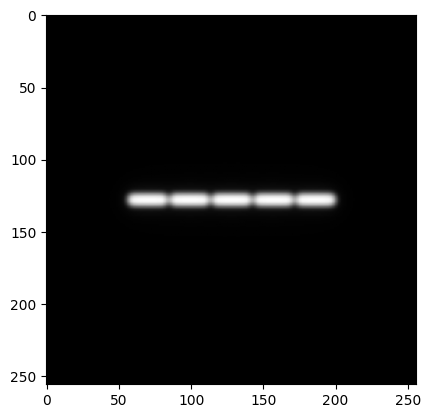

In [26]:
strepto = Streptobacillus(
    position=(128, 128)
)

optics = dt.Fluorescence(
    output_region=(0, 0, 256, 256)
)

pip = optics(strepto)

pip.update()
image = pip.resolve()
plt.imshow(image, cmap='gray');

By adjusting the number of bacilli, their length, and the bending parameters, it is possible to create different chain morphologies. This is one way to mimic the diversity that may appear in experiments.

In [27]:
strepto = Streptobacillus(
    position=lambda: np.random.uniform(50, 206, 2),
    n_bacilli=lambda: np.random.randint(3, 6),
    max_chain_bend=0.15e-6,
    max_bacillus_bend=0.15e-6,
    rotation=lambda: np.random.uniform(0, 2*np.pi),
)

optics = dt.Fluorescence(
    output_region=(0, 0, 256, 256)
)

pip = optics(strepto ^ 2)

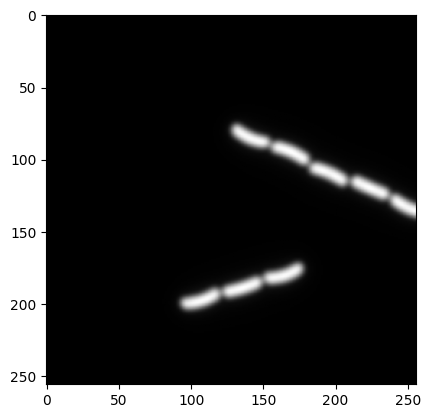

In [31]:
pip.update()
image = pip.resolve()
plt.imshow(image, cmap='gray');

### 3.3 Streptococcus:
Streptococci are spherical bacteria that typically grow in chains. A simple way to describe them is as a series of spheres arranged along an axis. The example `Streptococcus` class implements this approach, and also allows the chain to bend smoothly to better resemble natural growth patterns.

In [32]:
class Streptococcus(dt.Scatterer):
    __conversion_table__ = ConversionTable(
        radius=(u.meter, u.meter),
        length=(u.meter, u.meter),
        rotation=(u.radian, u.radian),
    )

    def __init__(
            self,
            radius=0.5e-6,
            n_coccus=5,
            rotation=(0, 0, 0),
            max_chain_bend=0,
            **kwargs
        ):
        super().__init__(
            radius=radius,
            n_coccus=n_coccus,
            rotation=rotation,
            max_chain_bend=max_chain_bend,
            **kwargs
        )

    def _process_properties(self, properties):
        properties = super()._process_properties(properties)

        # Ensure radius iis scalar
        radius = np.array(properties["radius"])
        if radius.size > 1:
            radius = radius[0]
        properties["radius"] = float(radius)

        # Ensure n_bacilli is int
        properties["n_coccus"] = int(properties.get("n_coccus"))

        # Ensure rotation is 3 values
        rotation = np.array(properties["rotation"])
        if rotation.ndim == 0:
            rotation = [rotation, 0, 0]
        elif rotation.size == 1:
            rotation = [rotation[0], 0, 0]
        elif rotation.size == 2:
            rotation = [rotation[0], rotation[1], 0]
        properties["rotation"] = tuple(rotation)

        return properties

    def get(
        self,
        *ignore,
        radius,
        n_coccus,
        rotation,
        max_chain_bend,
        voxel_size,
        **kwargs
    ):
        # Determine grid size
        rad_ceil = np.ceil(radius / np.min(voxel_size[:2]))
        len_ceil = rad_ceil * n_coccus
        ceil = len_ceil

        # Create grid
        x = np.arange(-ceil, ceil) * voxel_size[0]
        y = np.arange(-ceil, ceil) * voxel_size[1]
        z = np.arange(-ceil, ceil) * voxel_size[2]
        Y, X, Z = np.meshgrid(y, x, z)

        # Rotate the grid
        cos = np.cos(rotation)
        sin = np.sin(rotation)
        XR = (
            cos[0] * cos[1] * X
            + (cos[0] * sin[1] * sin[2] - sin[0] * cos[2]) * Y
            + (cos[0] * sin[1] * cos[2] + sin[0] * sin[2]) * Z
        )
        YR = (
            sin[0] * cos[1] * X
            + (sin[0] * sin[1] * sin[2] + cos[0] * cos[2]) * Y
            + (sin[0] * sin[1] * cos[2] - cos[0] * sin[2]) * Z
        )
        ZR = (-sin[1] * X) + cos[1] * sin[2] * Y + cos[1] * cos[2] * Z

        shift = 2 * radius
        total_length = n_coccus * 2 * radius

        mask = np.zeros_like(XR, dtype=bool)

        # Generate smooth random offsets along the chain
        bend_x_offsets = (np.random.rand(n_coccus) - 0.5) * 2 * max_chain_bend
        bend_z_offsets = (np.random.rand(n_coccus) - 0.5) * 2 * max_chain_bend
        
        # Smooth offsets for more natural curve
        for i in range(1, n_coccus):
            bend_x_offsets[i] = 0.7 * bend_x_offsets[i-1] + 0.3 * bend_x_offsets[i]
            bend_z_offsets[i] = 0.7 * bend_z_offsets[i-1] + 0.3 * bend_z_offsets[i]
        
        shift = 2 * radius
        total_length = n_coccus * shift
        
        for i in range(n_coccus):
            # Shift along Y and add realistic random bend
            YR_shifted = YR - i*shift + total_length/2 - shift/2
            XR_shifted = XR - bend_x_offsets[i]
            ZR_shifted = ZR - bend_z_offsets[i]
        
            coccus_mask = (XR_shifted**2 + YR_shifted**2 + ZR_shifted**2) < radius**2
            mask |= coccus_mask

        return mask.astype(float)

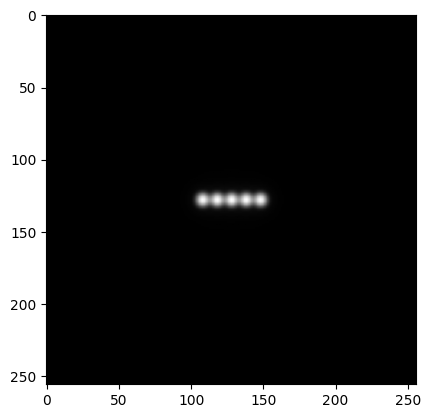

In [33]:
strepto = Streptococcus(
    position=(128, 128)
)

optics = dt.Fluorescence(
    output_region=(0, 0, 256, 256)
)

pip = optics(strepto)

pip.update()
image = pip.resolve()
plt.imshow(image, cmap='gray');

Parameters such as the number of spheres, their radius, and the amount of bending can be adjusted. As with the other examples, several chains can be placed in the same image to simulate more complex bacterial populations.

In [34]:
strepto = Streptococcus(
    position=lambda: np.random.uniform(50, 206, 2),
    n_coccus=lambda: np.random.randint(5, 12),
    max_chain_bend=1.5e-6,
    rotation=lambda: np.random.uniform(0, 2*np.pi),
)

optics = dt.Fluorescence(
    output_region=(0, 0, 256, 256)
)

pip = optics(strepto ^ 3)

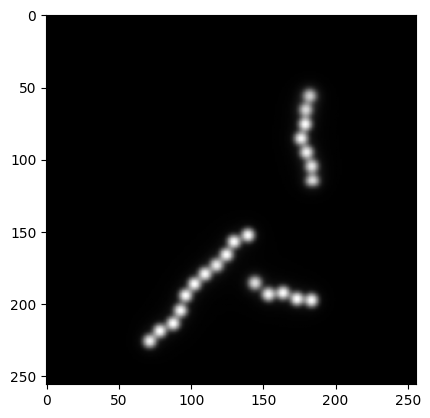

In [36]:
pip.update()
image = pip.resolve()
plt.imshow(image, cmap='gray');